# Experiment 3 — Implementation of Convolutional Neural Networks (CNNs) for Image Classification

**CS3807 – Deep Learning Laboratory** · Shiv Nadar University Chennai
**Name:** R S Kirithic &nbsp;·&nbsp; **Register No.:** 24011101082 &nbsp;·&nbsp; **Section:** AIDS 'B'

**Dataset:** CIFAR-10, loaded from Google Drive (`My Drive/DL/cifar-10-batches-py`), same as Experiment 4 — no download step.

**A few notes on choices the manual leaves open:**
- The manual's Task 6 diagram (`Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax`) doesn't give filter counts or kernel size. Following the 16-filter, 3x3 example already used in the manual's own parameter-calculation worked example (Section 6), the main CNN here uses **16 filters** in the first conv layer and **32** in the second, both **3x3**, and a single `Dense(10, softmax)` after flattening (no extra hidden dense layer, since the diagram only shows one).
- **Task 4** (visualizing feature maps) comes *before* Task 6 (building/training the CNN) in the manual, so it uses a **freshly initialized, untrained** Conv2D layer, the same way Tasks 2 and 3 use standalone demonstration layers — not the trained network's first layer.
- **Task 5** (max vs average pooling) and **Additional Exercise 4** ("replace max pooling with average pooling and compare") ask for the same comparison. Rather than train the average-pooling variant twice, Task 5 does it once and Exercise 4 just points back to it.
- Task 5's max-pooling arm is exactly Task 6's main CNN, so it isn't retrained a second time either — Task 5 only trains the new average-pooling variant and compares it against Task 6's already-trained results. That's why Task 5 appears in the notebook *after* Task 6, even though it's numbered earlier in the manual.
- Everything here runs on the **full** CIFAR-10 dataset (50,000 train / 10,000 test) — this is a lightweight CNN with no pretrained backbone, so there's no need to subsample anything the way the transfer-learning experiment did.
- Every plot saves as a separate 600 DPI `.eps` file, Times New Roman 13pt, straight to `My Drive/DL/Experiment3_Figures/`, same house style as before.

Run top to bottom, then send back everything it prints and I'll build the LaTeX report next.

## 0. Setup

In [1]:
# Install Times New Roman (Microsoft core fonts) for the matplotlib figures.
# Only needs to run once per fresh Colab runtime.
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | sudo debconf-set-selections
!apt-get install -y -qq ttf-mscorefonts-installer > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib
print("Font install step done.")

Font install step done.


In [2]:
import os, glob, time, pickle, zipfile, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

from google.colab import drive
drive.mount('/content/drive')

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Paths ----
DATASET_DIR = "/content/drive/MyDrive/DL/cifar-10-batches-py"
FIG_DIR = "/content/drive/MyDrive/DL/Experiment3_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

assert os.path.isdir(DATASET_DIR), (
    f"Could not find {DATASET_DIR}. Update DATASET_DIR to point at your "
    f"cifar-10-batches-py folder in Drive."
)
print("Dataset folder found:", DATASET_DIR)
print("Contents:", sorted(os.listdir(DATASET_DIR)))

# ---- Plot style: Times New Roman, size 13, saved as 600 DPI EPS ----
for fp in glob.glob('/usr/share/fonts/truetype/msttcorefonts/*Times*'):
    try:
        fm.fontManager.addfont(fp)
    except Exception as e:
        print("Could not register font:", fp, e)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 13

def save_fig(fig, name):
    """Save a matplotlib figure as a 600 DPI EPS file in FIG_DIR."""
    path = os.path.join(FIG_DIR, f"{name}.eps")
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print("Saved:", path)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
Dataset folder found: /content/drive/MyDrive/DL/cifar-10-batches-py
Contents: ['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'readme.html', 'test_batch']
TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1: Dataset Preparation

In [3]:
def unpickle(file_path):
    with open(file_path, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

def batch_to_arrays(d):
    raw = d[b'data']
    labels = np.array(d[b'labels'], dtype=np.int64)
    images = raw.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return images, labels

train_images, train_labels = [], []
for i in range(1, 6):
    d = unpickle(os.path.join(DATASET_DIR, f"data_batch_{i}"))
    imgs, labs = batch_to_arrays(d)
    train_images.append(imgs)
    train_labels.append(labs)
X_train_raw = np.concatenate(train_images, axis=0)
y_train_int = np.concatenate(train_labels, axis=0)

d_test = unpickle(os.path.join(DATASET_DIR, "test_batch"))
X_test_raw, y_test_int = batch_to_arrays(d_test)

meta = unpickle(os.path.join(DATASET_DIR, "batches.meta"))
label_names = [x.decode('utf-8') for x in meta[b'label_names']]
NUM_CLASSES = len(label_names)
print("Classes:", label_names)

X_train = X_train_raw.astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0
y_train_onehot = tf.keras.utils.to_categorical(y_train_int, NUM_CLASSES)
y_test_onehot = tf.keras.utils.to_categorical(y_test_int, NUM_CLASSES)

print(f"Pixel value range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train_onehot.shape)
print("Testing images shape :", X_test.shape)
print("Testing labels shape :", y_test_onehot.shape)
print("Number of classes    :", NUM_CLASSES)
print("Image size           : 32 x 32 x 3")

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Pixel value range: [0.00, 1.00]
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Testing images shape : (10000, 32, 32, 3)
Testing labels shape : (10000, 10)
Number of classes    : 10
Image size           : 32 x 32 x 3


Saved: /content/drive/MyDrive/DL/Experiment3_Figures/01_sample_images.eps


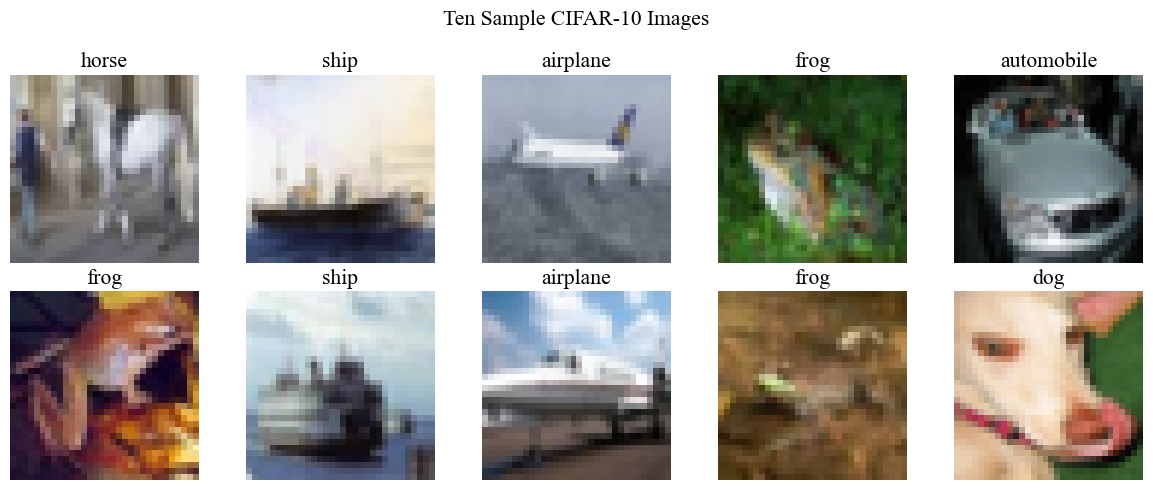

In [4]:
# ---- Display ten sample images ----
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
sample_idx = np.random.choice(len(X_train), 10, replace=False)
for idx, ax in zip(sample_idx, axes.flat):
    ax.imshow(X_train[idx])
    ax.set_title(label_names[y_train_int[idx]])
    ax.axis('off')
fig.suptitle("Ten Sample CIFAR-10 Images")
plt.tight_layout()
save_fig(fig, "01_sample_images")
plt.show()

Saved: /content/drive/MyDrive/DL/Experiment3_Figures/02_class_distribution.eps


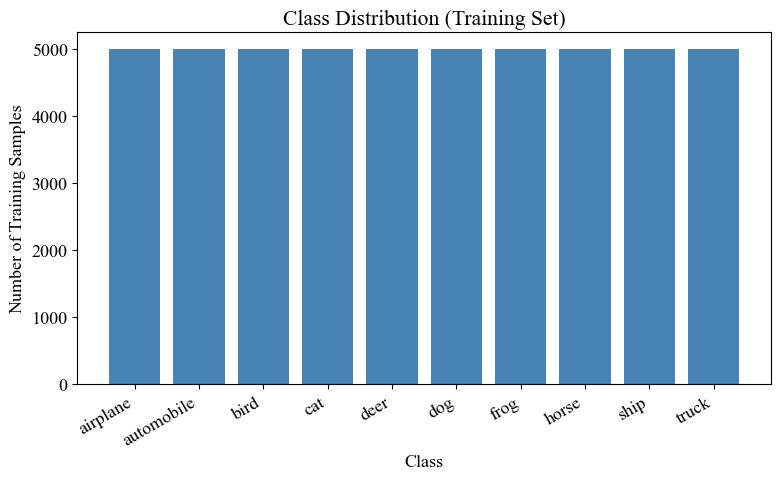

Samples per class: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


In [5]:
# ---- Class distribution ----
counts = np.bincount(y_train_int, minlength=NUM_CLASSES)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(label_names, counts, color='steelblue')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Training Samples')
ax.set_title('Class Distribution (Training Set)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_fig(fig, "02_class_distribution")
plt.show()
print("Samples per class:", dict(zip(label_names, counts.tolist())))

## Task 2: Convolution Layer — Kernel Size Comparison

A single-filter convolution (`valid` padding, stride 1) is applied to one sample image using
3x3, 5x5 and 7x7 kernels, and the resulting feature map sizes are recorded and checked against
the formula $\frac{N-F+2P}{S}+1$ from Section 3.

Saved: /content/drive/MyDrive/DL/Experiment3_Figures/03_kernel_size_comparison.eps


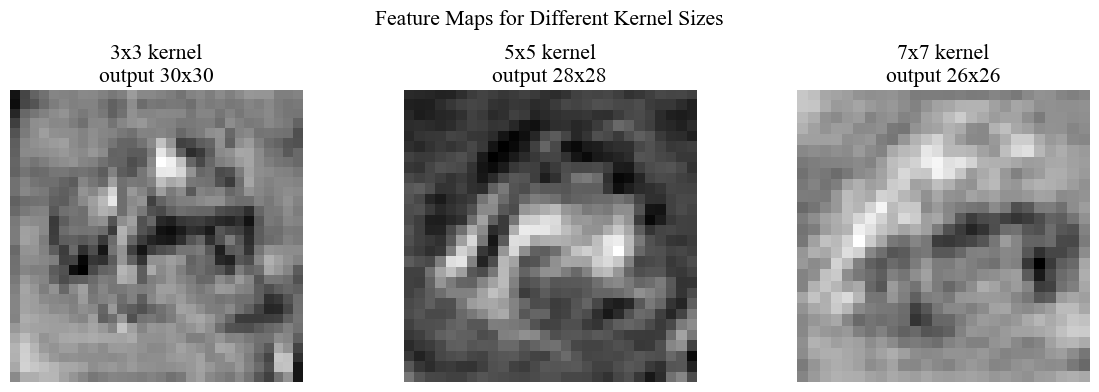

kernel_size output_shape  expected_size
        3x3     (30, 30)             30
        5x5     (28, 28)             28
        7x7     (26, 26)             26


In [6]:
demo_image = X_train[0:1]  # (1, 32, 32, 3)
kernel_sizes = [3, 5, 7]
kernel_results = []

fig, axes = plt.subplots(1, len(kernel_sizes), figsize=(4 * len(kernel_sizes), 4))
for ax, k in zip(axes, kernel_sizes):
    layer = layers.Conv2D(filters=1, kernel_size=k, strides=1, padding='valid')
    out = layer(demo_image)
    N, F, S, P = 32, k, 1, 0
    expected = (N - F + 2 * P) // S + 1
    kernel_results.append({'kernel_size': f"{k}x{k}", 'output_shape': tuple(out.shape[1:3]),
                            'expected_size': expected})
    ax.imshow(out[0, :, :, 0], cmap='gray')
    ax.set_title(f"{k}x{k} kernel\noutput {out.shape[1]}x{out.shape[2]}")
    ax.axis('off')
fig.suptitle("Feature Maps for Different Kernel Sizes")
plt.tight_layout()
save_fig(fig, "03_kernel_size_comparison")
plt.show()

kernel_df = pd.DataFrame(kernel_results)
print(kernel_df.to_string(index=False))

## Task 3: Stride and Padding

The same demonstration image and a fixed 3x3 kernel are used to compare stride 1 vs stride 2,
and `same` vs `valid` padding, again checked against the output-size formula.

In [7]:
stride_padding_configs = [
    {'stride': 1, 'padding': 'valid'},
    {'stride': 2, 'padding': 'valid'},
    {'stride': 1, 'padding': 'same'},
    {'stride': 2, 'padding': 'same'},
]
sp_results = []
for cfg in stride_padding_configs:
    layer = layers.Conv2D(filters=1, kernel_size=3, strides=cfg['stride'], padding=cfg['padding'])
    out = layer(demo_image)
    sp_results.append({'stride': cfg['stride'], 'padding': cfg['padding'],
                        'output_shape': tuple(out.shape[1:3])})

sp_df = pd.DataFrame(sp_results)
print("=== Task 3: Stride / Padding Output Dimensions ===")
print(sp_df.to_string(index=False))

=== Task 3: Stride / Padding Output Dimensions ===
 stride padding output_shape
      1   valid     (30, 30)
      2   valid     (15, 15)
      1    same     (32, 32)
      2    same     (16, 16)


## Task 4: Feature Map Visualization

A freshly initialized (untrained) Conv2D layer with 16 filters is applied to a sample image, and
8 of the resulting feature maps are displayed — this comes before Task 6, so there is no trained
network yet to draw the layer from.

Saved: /content/drive/MyDrive/DL/Experiment3_Figures/04_feature_maps.eps


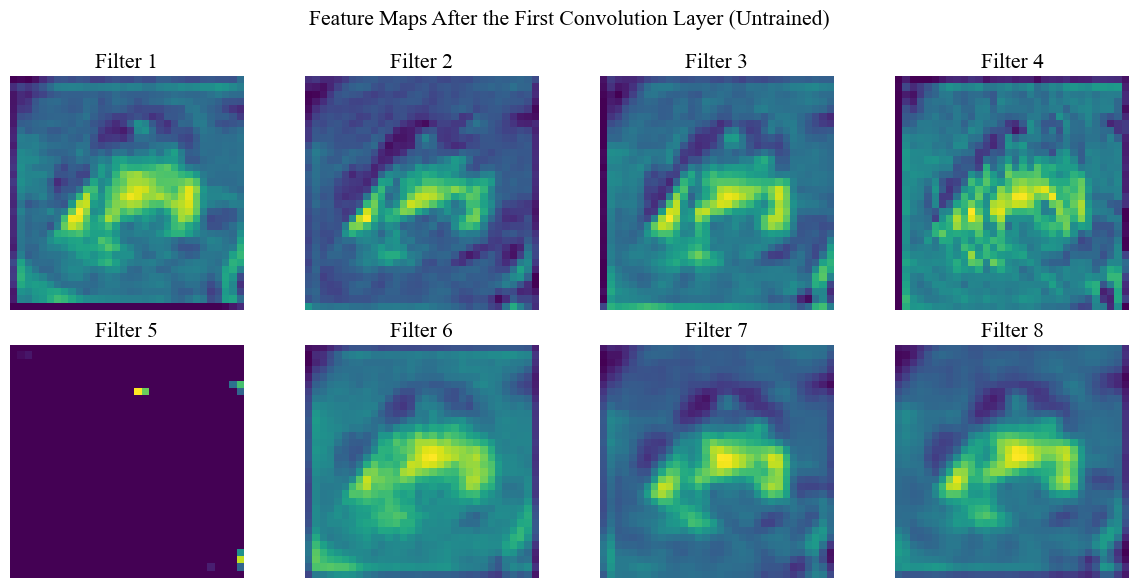

In [8]:
demo_conv_layer = layers.Conv2D(filters=16, kernel_size=3, padding='same', activation='relu')
demo_feature_maps = demo_conv_layer(demo_image)[0]  # (32, 32, 16)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(demo_feature_maps[:, :, i], cmap='viridis')
    ax.set_title(f"Filter {i + 1}")
    ax.axis('off')
fig.suptitle("Feature Maps After the First Convolution Layer (Untrained)")
plt.tight_layout()
save_fig(fig, "04_feature_maps")
plt.show()

## Task 6: Building and Training the Main CNN

`Input -> Conv(16, 3x3) -> ReLU -> MaxPool -> Conv(32, 3x3) -> ReLU -> MaxPool -> Flatten -> Dense(10) -> Softmax`,
trained with Adam, 20 epochs, batch size 32, on the full training set with a 90/10 validation split.

In [9]:
def build_cnn(conv1_filters=16, conv2_filters=32, kernel_size=3, activation='relu',
              pooling='max', input_shape=(32, 32, 3), num_classes=NUM_CLASSES, name="CNN"):
    PoolLayer = layers.MaxPooling2D if pooling == 'max' else layers.AveragePooling2D
    model = models.Sequential(name=name)
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(conv1_filters, kernel_size, padding='same', activation=activation))
    model.add(PoolLayer(2))
    model.add(layers.Conv2D(conv2_filters, kernel_size, padding='same', activation=activation))
    model.add(PoolLayer(2))
    model.add(layers.Flatten())
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

MAIN_EPOCHS = 20
BATCH_SIZE = 32

X_tr, X_val, y_tr_int, y_val_int = train_test_split(
    X_train, y_train_int, test_size=0.1, random_state=SEED, stratify=y_train_int)
y_tr_oh = tf.keras.utils.to_categorical(y_tr_int, NUM_CLASSES)
y_val_oh = tf.keras.utils.to_categorical(y_val_int, NUM_CLASSES)
print("Train / Val / Test sizes:", len(X_tr), len(X_val), len(X_test))

main_cnn = build_cnn(conv1_filters=16, conv2_filters=32, pooling='max', name="Main_CNN_MaxPool")
main_cnn.summary()
main_cnn.compile(optimizer=optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
history_main = main_cnn.fit(X_tr, y_tr_oh, validation_data=(X_val, y_val_oh),
                             epochs=MAIN_EPOCHS, batch_size=BATCH_SIZE, verbose=1)
main_train_time = time.time() - t0
print(f"\nMain CNN training time: {main_train_time:.2f} seconds ({MAIN_EPOCHS} epochs)")
main_params = main_cnn.count_params()
print("Total parameters:", main_params)

Train / Val / Test sizes: 45000 5000 10000


Model: "Main_CNN_MaxPool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,578 (99.91 KB)

 Trainable params: 25,578 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4549 - loss: 1.5342 - val_accuracy: 0.5642 - val_loss: 1.2525
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5734 - loss: 1.2126 - val_accuracy: 0.6150 - val_loss: 1.1154
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6199 - loss: 1.0911 - val_accuracy: 0.6392 - val_loss: 1.0463
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6469 - loss: 1.0141 - val_accuracy: 0.6560 - val_loss: 1.0097
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6663 - loss: 0.9607 - val_accuracy: 0.6650 - val_loss: 0.9909
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6808 - loss: 0.9199 - val_accuracy: 0.6652 - val_loss: 0.9811
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6941 - loss: 0.8861 - val_accuracy: 0.6650 - val_loss: 0.9789
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7033 - loss: 0.8579 -

Saved: /content/drive/MyDrive/DL/Experiment3_Figures/05_training_accuracy.eps


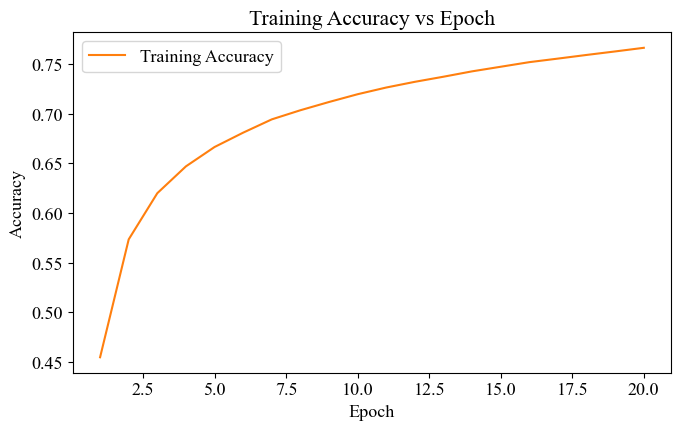

Saved: /content/drive/MyDrive/DL/Experiment3_Figures/06_validation_accuracy.eps


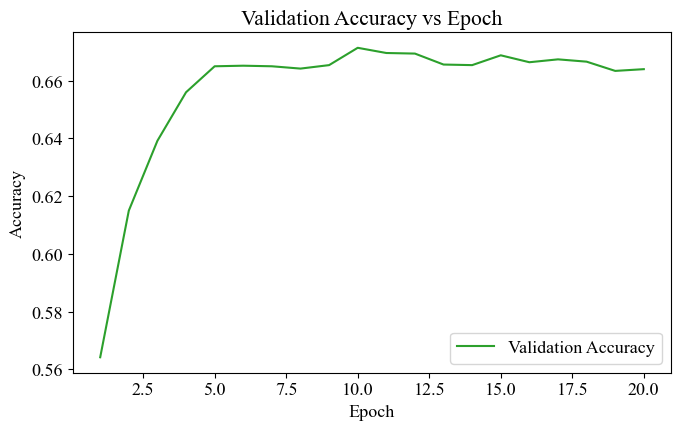

Saved: /content/drive/MyDrive/DL/Experiment3_Figures/07_training_loss.eps


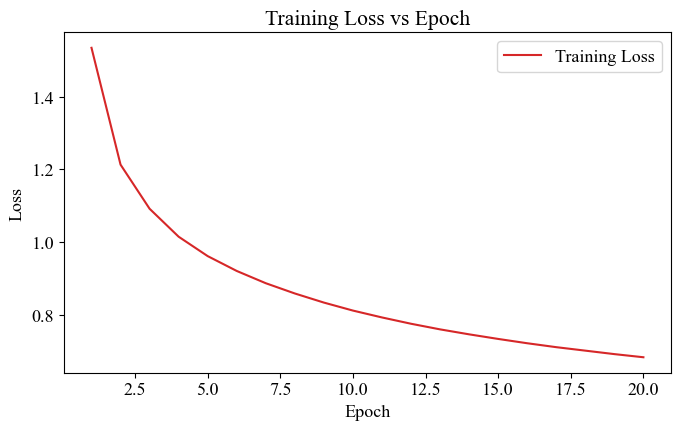

Saved: /content/drive/MyDrive/DL/Experiment3_Figures/08_validation_loss.eps


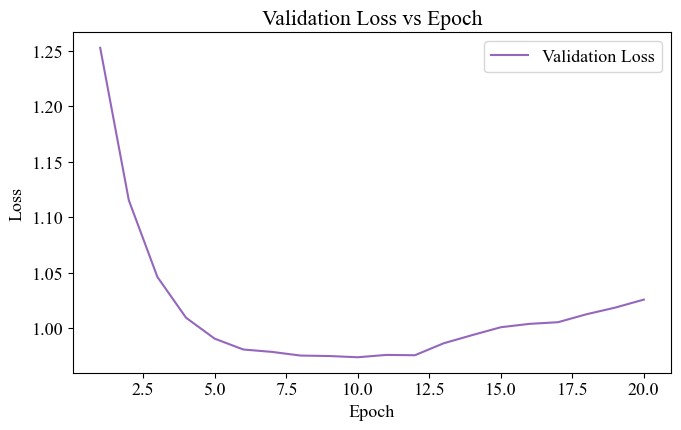

In [10]:
# ---- Mandatory plots: training/validation accuracy and loss ----
def plot_curve(values, label, ylabel, color, fname):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(range(1, len(values) + 1), values, color=color, label=label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{label} vs Epoch')
    ax.legend()
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()

plot_curve(history_main.history['accuracy'], 'Training Accuracy', 'Accuracy', 'tab:orange', "05_training_accuracy")
plot_curve(history_main.history['val_accuracy'], 'Validation Accuracy', 'Accuracy', 'tab:green', "06_validation_accuracy")
plot_curve(history_main.history['loss'], 'Training Loss', 'Loss', 'tab:red', "07_training_loss")
plot_curve(history_main.history['val_loss'], 'Validation Loss', 'Loss', 'tab:purple', "08_validation_loss")

## Task 7: Model Evaluation

In [11]:
y_pred_probs = main_cnn.predict(X_test, verbose=0)
y_pred_int = np.argmax(y_pred_probs, axis=1)

main_acc = accuracy_score(y_test_int, y_pred_int)
main_prec = precision_score(y_test_int, y_pred_int, average='weighted', zero_division=0)
main_rec = recall_score(y_test_int, y_pred_int, average='weighted', zero_division=0)
main_f1 = f1_score(y_test_int, y_pred_int, average='weighted', zero_division=0)
main_train_acc = history_main.history['accuracy'][-1]

print("=== Main CNN (Max Pooling) — Test Evaluation ===")
print(f"Training Accuracy : {main_train_acc:.4f}")
print(f"Testing Accuracy  : {main_acc:.4f}")
print(f"Precision         : {main_prec:.4f}")
print(f"Recall            : {main_rec:.4f}")
print(f"F1-score          : {main_f1:.4f}")
print(f"Training Time     : {main_train_time:.2f} seconds")
print(f"Total Parameters  : {main_params:,}")
print("\nClassification Report:")
print(classification_report(y_test_int, y_pred_int, target_names=label_names, zero_division=0))

=== Main CNN (Max Pooling) — Test Evaluation ===
Training Accuracy : 0.7661
Testing Accuracy  : 0.6584
Precision         : 0.6677
Recall            : 0.6584
F1-score          : 0.6604
Training Time     : 115.95 seconds
Total Parameters  : 25,578

Classification Report:
              precision    recall  f1-score   support

    airplane       0.68      0.71      0.69      1000
  automobile       0.83      0.74      0.78      1000
        bird       0.60      0.50      0.55      1000
         cat       0.43      0.53      0.47      1000
        deer       0.59      0.62      0.60      1000
         dog       0.58      0.55      0.57      1000
        frog       0.81      0.66      0.73      1000
       horse       0.67      0.75      0.71      1000
        ship       0.72      0.81      0.76      1000
       truck       0.77      0.72      0.74      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67   

Saved: /content/drive/MyDrive/DL/Experiment3_Figures/09_confusion_matrix.eps


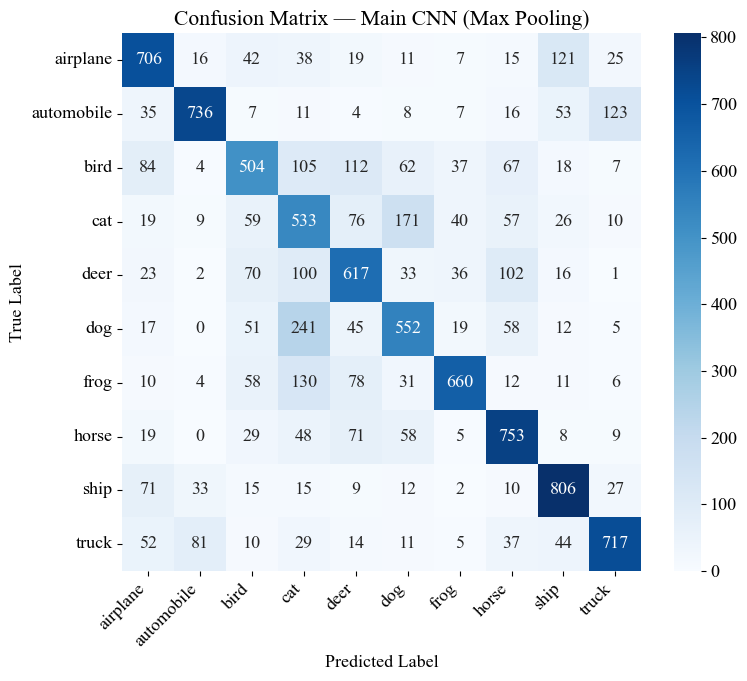

In [12]:
cm = confusion_matrix(y_test_int, y_pred_int)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names,
            yticklabels=label_names, ax=ax, cbar=True)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Main CNN (Max Pooling)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_fig(fig, "09_confusion_matrix")
plt.show()

## Task 5: Max Pooling vs Average Pooling

The main CNN above already is the max-pooling arm of this comparison, so only the
average-pooling variant is trained here, with everything else kept identical.

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4443 - loss: 1.5601 - val_accuracy: 0.5354 - val_loss: 1.3081
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5508 - loss: 1.2770 - val_accuracy: 0.5752 - val_loss: 1.2026
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5876 - loss: 1.1758 - val_accuracy: 0.6028 - val_loss: 1.1194
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6194 - loss: 1.0904 - val_accuracy: 0.6344 - val_loss: 1.0548
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6435 - loss: 1.0249 - val_accuracy: 0.6492 - val_loss: 1.0126
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6603 - loss: 0.9765 - val_accuracy: 0.6580 - val_loss: 0.9834
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6727 - loss: 0.9390 - val_accuracy: 0.6634 - val_loss: 0.9632
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6830 - loss: 0.9081 - 

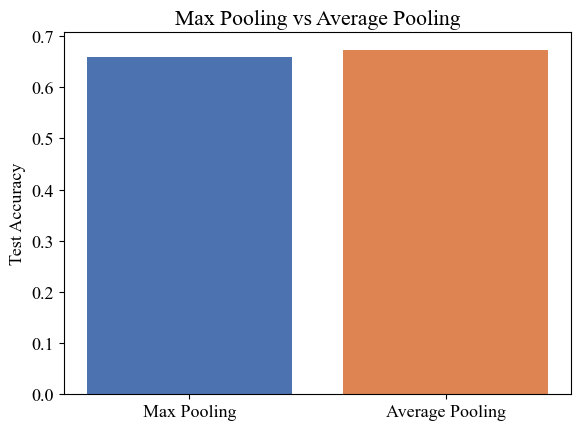

In [13]:
avgpool_cnn = build_cnn(conv1_filters=16, conv2_filters=32, pooling='avg', name="CNN_AvgPool")
avgpool_cnn.compile(optimizer=optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
history_avgpool = avgpool_cnn.fit(X_tr, y_tr_oh, validation_data=(X_val, y_val_oh),
                                   epochs=MAIN_EPOCHS, batch_size=BATCH_SIZE, verbose=1)
avgpool_train_time = time.time() - t0

y_pred_avg = np.argmax(avgpool_cnn.predict(X_test, verbose=0), axis=1)
avgpool_acc = accuracy_score(y_test_int, y_pred_avg)
avgpool_params = avgpool_cnn.count_params()

# Output shape after the first pooling layer, for both variants
max_pool_out_shape = main_cnn.layers[1].output.shape[1:3]
avg_pool_out_shape = avgpool_cnn.layers[1].output.shape[1:3]

print("=== Task 5: Max Pooling vs Average Pooling ===")
print(f"Max Pooling : test accuracy = {main_acc:.4f} | first-pool output shape = {tuple(max_pool_out_shape)} "
      f"| training time = {main_train_time:.2f}s")
print(f"Avg Pooling : test accuracy = {avgpool_acc:.4f} | first-pool output shape = {tuple(avg_pool_out_shape)} "
      f"| training time = {avgpool_train_time:.2f}s")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['Max Pooling', 'Average Pooling'], [main_acc, avgpool_acc], color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Test Accuracy')
ax.set_title('Max Pooling vs Average Pooling')
plt.tight_layout()
save_fig(fig, "10_pooling_comparison")
plt.show()

## Additional Exercises

### Exercise 1 — Output Size for a 64x64 Image, 5x5 Kernel, Stride 2, Padding 2

In [14]:
N, F, S, P = 64, 5, 2, 2
expected_out = (N - F + 2 * P) // S + 1
print(f"Formula: floor(({N} - {F} + 2*{P}) / {S}) + 1 = {expected_out}")

dummy_image = tf.zeros((1, N, N, 3))
verify_layer = models.Sequential([
    layers.Input(shape=(N, N, 3)),
    layers.ZeroPadding2D(padding=P),
    layers.Conv2D(filters=1, kernel_size=F, strides=S, padding='valid'),
])
verify_out = verify_layer(dummy_image)
print("Verified with an actual Conv2D layer, output shape:", tuple(verify_out.shape[1:3]))

Formula: floor((64 - 5 + 2*2) / 2) + 1 = 32
Verified with an actual Conv2D layer, output shape: (32, 32)


### Exercise 2 — Trainable Parameters for 64 Filters, 3x3 Kernel, RGB Input

In [15]:
filters, kernel, channels = 64, 3, 3
expected_params = (kernel * kernel * channels + 1) * filters
print(f"Formula: ({kernel}x{kernel}x{channels} + 1) x {filters} = {expected_params}")

verify_conv = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(filters=filters, kernel_size=kernel, padding='same'),
])
print("Verified with an actual Conv2D layer, parameter count:", verify_conv.count_params())

Formula: (3x3x3 + 1) x 64 = 1792
Verified with an actual Conv2D layer, parameter count: 1792


### Exercise 3 — ReLU vs Sigmoid Activation

In [16]:
sigmoid_cnn = build_cnn(conv1_filters=16, conv2_filters=32, activation='sigmoid',
                         pooling='max', name="CNN_Sigmoid")
sigmoid_cnn.compile(optimizer=optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
history_sigmoid = sigmoid_cnn.fit(X_tr, y_tr_oh, validation_data=(X_val, y_val_oh),
                                   epochs=MAIN_EPOCHS, batch_size=BATCH_SIZE, verbose=1)
sigmoid_train_time = time.time() - t0

y_pred_sig = np.argmax(sigmoid_cnn.predict(X_test, verbose=0), axis=1)
sigmoid_acc = accuracy_score(y_test_int, y_pred_sig)

print("=== Exercise 3: ReLU vs Sigmoid ===")
print(f"ReLU (Main CNN) : test accuracy = {main_acc:.4f} | training time = {main_train_time:.2f}s")
print(f"Sigmoid         : test accuracy = {sigmoid_acc:.4f} | training time = {sigmoid_train_time:.2f}s")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2467 - loss: 2.0659 - val_accuracy: 0.3498 - val_loss: 1.8551
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3724 - loss: 1.7663 - val_accuracy: 0.4084 - val_loss: 1.6947
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4149 - loss: 1.6510 - val_accuracy: 0.4364 - val_loss: 1.6159
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4408 - loss: 1.5862 - val_accuracy: 0.4520 - val_loss: 1.5627
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4577 - loss: 1.5329 - val_accuracy: 0.4738 - val_loss: 1.5158
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4748 - loss: 1.4850 - val_accuracy: 0.4856 - val_loss: 1.4712
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4916 - loss: 1.4403 - val_accuracy: 0.4932 - val_loss: 1.4258
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5071 - loss: 1.3973 - 

### Exercise 4 — Replace Max Pooling with Average Pooling

In [17]:
print("=== Exercise 4: Max Pooling vs Average Pooling ===")
print("This is the same comparison as Task 5 above, so it isn't repeated here.")
print(f"Max Pooling : test accuracy = {main_acc:.4f}")
print(f"Avg Pooling : test accuracy = {avgpool_acc:.4f}")

=== Exercise 4: Max Pooling vs Average Pooling ===
This is the same comparison as Task 5 above, so it isn't repeated here.
Max Pooling : test accuracy = 0.6584
Avg Pooling : test accuracy = 0.6738


### Exercise 5 — Increasing Filters from 16 to 64

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4680 - loss: 1.4990 - val_accuracy: 0.5670 - val_loss: 1.2459
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5874 - loss: 1.1845 - val_accuracy: 0.6246 - val_loss: 1.0863
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6332 - loss: 1.0570 - val_accuracy: 0.6538 - val_loss: 1.0028
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6594 - loss: 0.9809 - val_accuracy: 0.6650 - val_loss: 0.9646
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6797 - loss: 0.9266 - val_accuracy: 0.6742 - val_loss: 0.9405
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6954 - loss: 0.8839 - val_accuracy: 0.6798 - val_loss: 0.9262
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7067 - loss: 0.8507 - val_accuracy: 0.6830 - val_loss: 0.9180
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7156 - loss: 0.8230 -

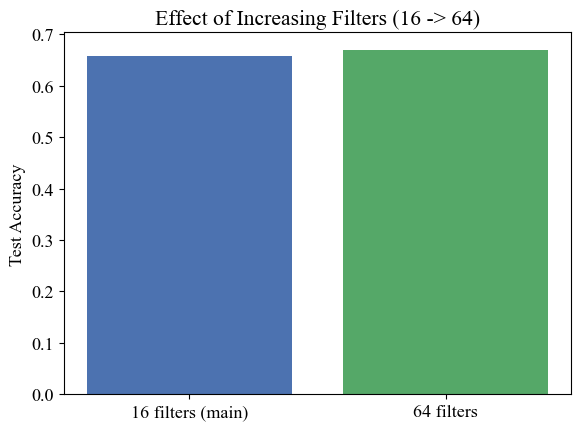

In [18]:
wide_cnn = build_cnn(conv1_filters=64, conv2_filters=32, pooling='max', name="CNN_64Filters")
wide_cnn.compile(optimizer=optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
history_wide = wide_cnn.fit(X_tr, y_tr_oh, validation_data=(X_val, y_val_oh),
                             epochs=MAIN_EPOCHS, batch_size=BATCH_SIZE, verbose=1)
wide_train_time = time.time() - t0

y_pred_wide = np.argmax(wide_cnn.predict(X_test, verbose=0), axis=1)
wide_acc = accuracy_score(y_test_int, y_pred_wide)
wide_params = wide_cnn.count_params()

print("=== Exercise 5: 16 Filters vs 64 Filters (first conv layer) ===")
print(f"16 filters (Main CNN) : test accuracy = {main_acc:.4f} | params = {main_params:,} | "
      f"training time = {main_train_time:.2f}s")
print(f"64 filters            : test accuracy = {wide_acc:.4f} | params = {wide_params:,} | "
      f"training time = {wide_train_time:.2f}s")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['16 filters (main)', '64 filters'], [main_acc, wide_acc], color=['#4C72B0', '#55A868'])
ax.set_ylabel('Test Accuracy')
ax.set_title('Effect of Increasing Filters (16 -> 64)')
plt.tight_layout()
save_fig(fig, "11_filter_count_comparison")
plt.show()

## Consolidated Results (for the report)

In [19]:
print("############################################")
print("# SECTION 11 — RESULTS (MAIN CNN)           #")
print("############################################")
print(f"Training Accuracy : {main_train_acc:.4f}")
print(f"Testing Accuracy  : {main_acc:.4f}")
print(f"Precision         : {main_prec:.4f}")
print(f"Recall            : {main_rec:.4f}")
print(f"F1-score          : {main_f1:.4f}")
print(f"Number of Parameters : {main_params:,}")

print("\n############################################")
print("# TASK 2 — KERNEL SIZE COMPARISON            #")
print("############################################")
print(kernel_df.to_string(index=False))

print("\n############################################")
print("# TASK 3 — STRIDE / PADDING COMPARISON       #")
print("############################################")
print(sp_df.to_string(index=False))

print("\n############################################")
print("# TASK 5 / EXERCISE 4 — POOLING COMPARISON   #")
print("############################################")
print(f"Max Pooling : acc={main_acc:.4f}  first-pool shape={tuple(max_pool_out_shape)}  time={main_train_time:.2f}s")
print(f"Avg Pooling : acc={avgpool_acc:.4f}  first-pool shape={tuple(avg_pool_out_shape)}  time={avgpool_train_time:.2f}s")

print("\n############################################")
print("# ADDITIONAL EXERCISES 1-2 — CALCULATIONS    #")
print("############################################")
print(f"Ex1 output size (64x64, 5x5 kernel, stride2, pad2): {expected_out}")
print(f"Ex2 trainable parameters (64 filters, 3x3, RGB)   : {expected_params}")

print("\n############################################")
print("# ADDITIONAL EXERCISE 3 — RELU VS SIGMOID    #")
print("############################################")
print(f"ReLU    : acc={main_acc:.4f}  time={main_train_time:.2f}s")
print(f"Sigmoid : acc={sigmoid_acc:.4f}  time={sigmoid_train_time:.2f}s")

print("\n############################################")
print("# ADDITIONAL EXERCISE 5 — FILTER COUNT       #")
print("############################################")
print(f"16 filters : acc={main_acc:.4f}  params={main_params:,}  time={main_train_time:.2f}s")
print(f"64 filters : acc={wide_acc:.4f}  params={wide_params:,}  time={wide_train_time:.2f}s")

############################################
# SECTION 11 — RESULTS (MAIN CNN)           #
############################################
Training Accuracy : 0.7661
Testing Accuracy  : 0.6584
Precision         : 0.6677
Recall            : 0.6584
F1-score          : 0.6604
Number of Parameters : 25,578

############################################
# TASK 2 — KERNEL SIZE COMPARISON            #
############################################
kernel_size output_shape  expected_size
        3x3     (30, 30)             30
        5x5     (28, 28)             28
        7x7     (26, 26)             26

############################################
# TASK 3 — STRIDE / PADDING COMPARISON       #
############################################
 stride padding output_shape
      1   valid     (30, 30)
      2   valid     (15, 15)
      1    same     (32, 32)
      2    same     (16, 16)

############################################
# TASK 5 / EXERCISE 4 — POOLING COMPARISON   #
#########################

## Save / Download All Figures

In [20]:
zip_path = "/content/Experiment3_Figures.zip"
with zipfile.ZipFile(zip_path, 'w') as zf:
    for f in sorted(glob.glob(os.path.join(FIG_DIR, "*.eps"))):
        zf.write(f, arcname=os.path.basename(f))
print("Zipped", len(glob.glob(os.path.join(FIG_DIR, '*.eps'))), "figures ->", zip_path)

from google.colab import files
files.download(zip_path)

Zipped 11 figures -> /content/Experiment3_Figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>